In [148]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn import metrics
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as mse
import warnings
warnings.filterwarnings('ignore')

In [149]:
df=pd.read_csv("tips.csv")

In [150]:
df.head(5)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [151]:
df.shape

(244, 7)

In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [153]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [154]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

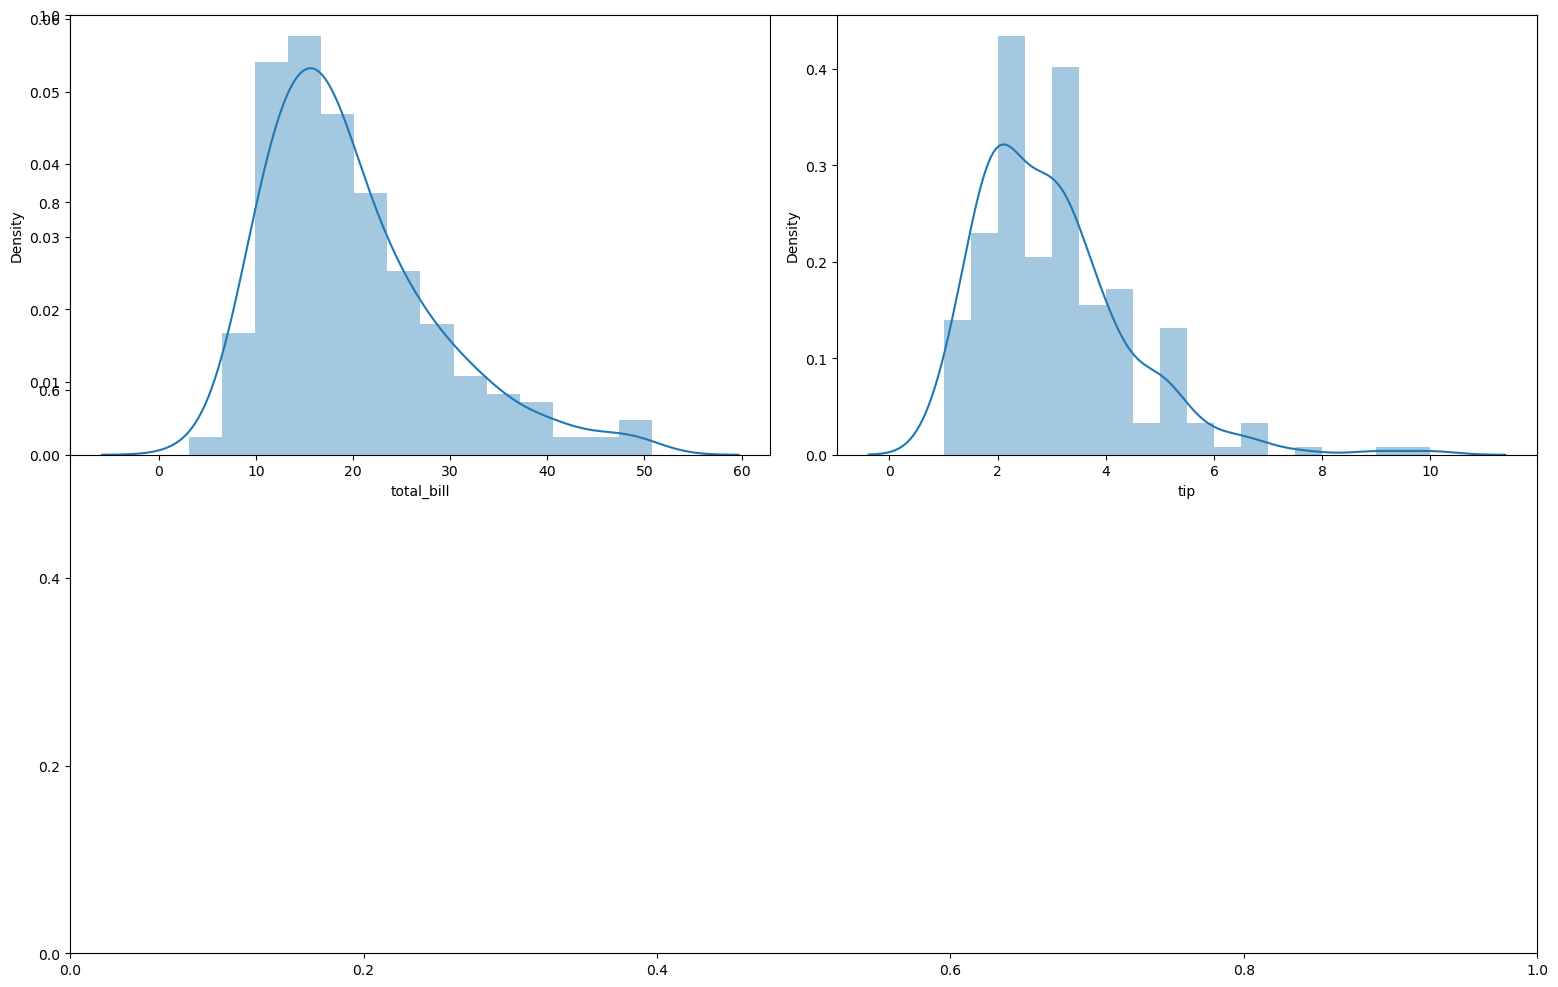

In [155]:
plt.subplots(figsize=(16,10))
for i, col in enumerate(['total_bill', 'tip']):
  plt.subplot(2,2, i + 1)
  sns.distplot(df[col])
plt.tight_layout()
plt.show()

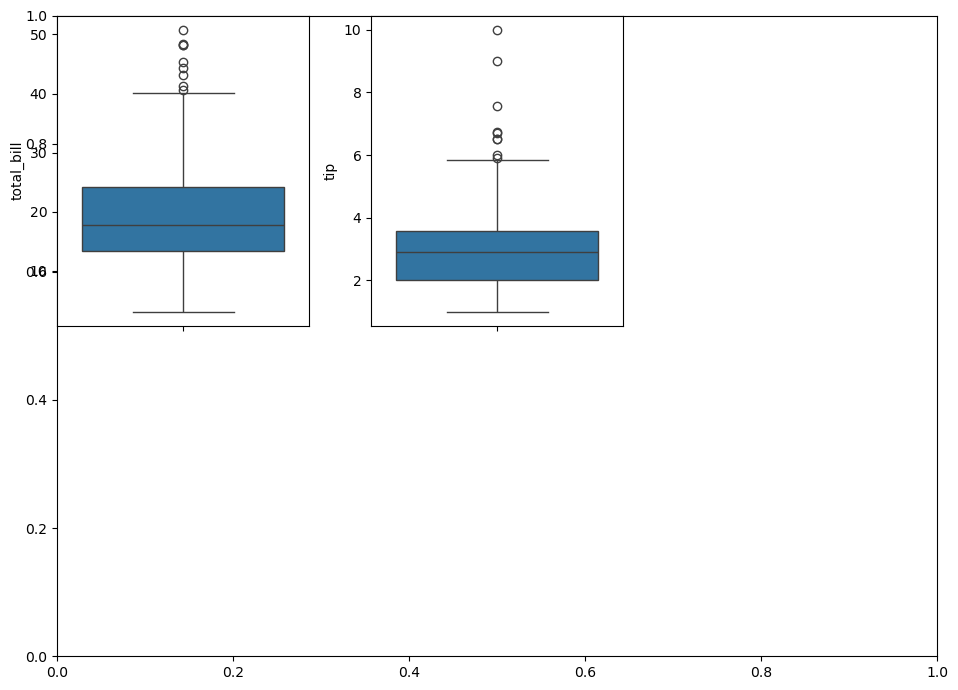

In [156]:
plt.subplots(figsize=(10,7))
for i, col in enumerate(["total_bill","tip"]):
    plt.subplot(2,3 ,i+1)
    sns.boxplot(df[col])
plt.tight_layout()
plt.show()

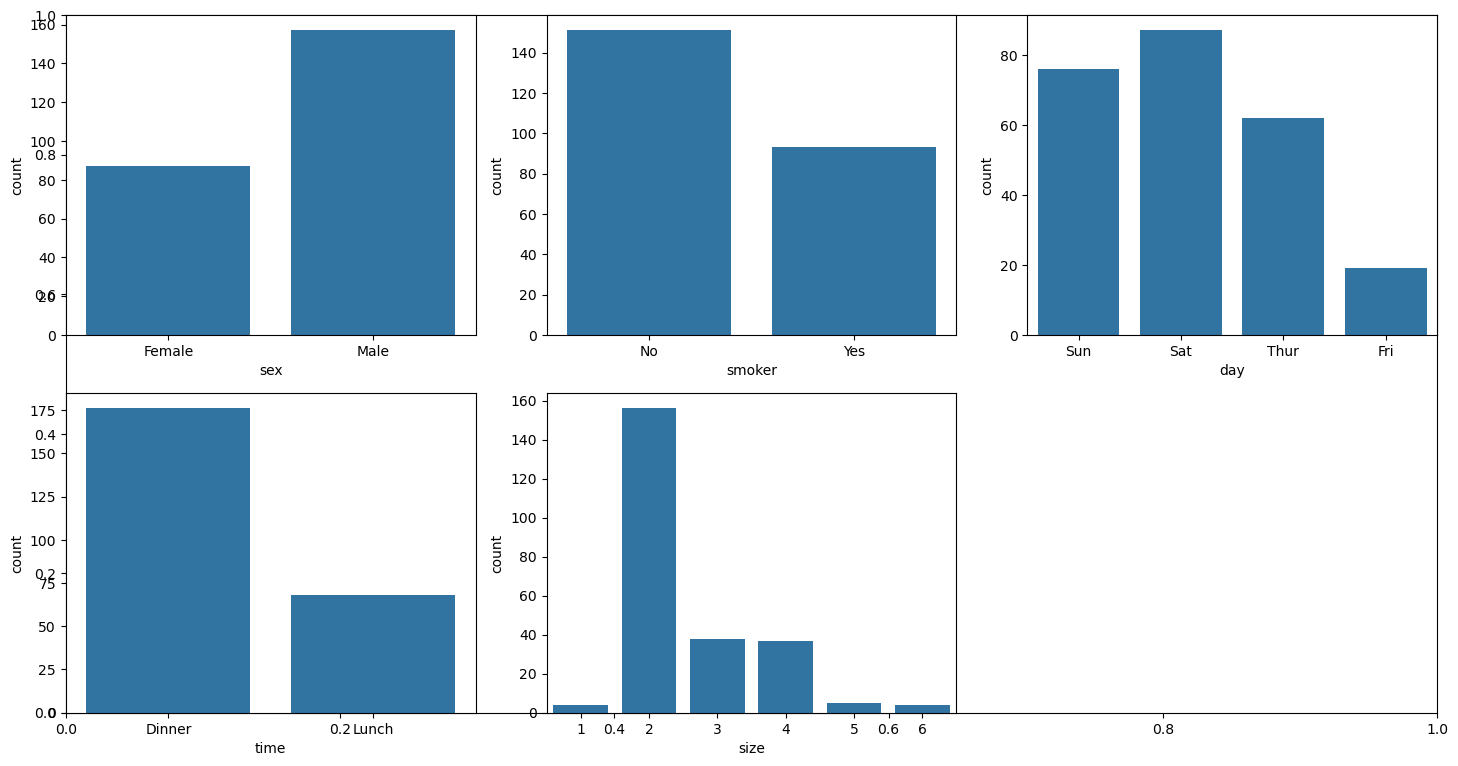

In [157]:
feat = df.loc[:,'sex':'size'].columns

plt.subplots(figsize=(15,8))
for i, col in enumerate(feat):
  plt.subplot(2,3, i + 1)
  sns.countplot(data=df, x=df[col])
plt.tight_layout()
plt.show()


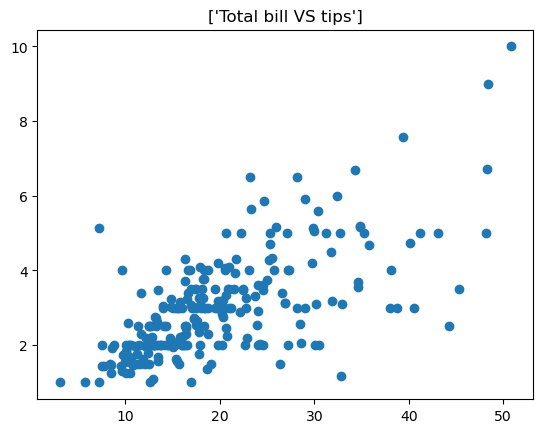

In [158]:
plt.scatter(df["total_bill"],df["tip"])
plt.title(["Total bill VS tips"])
plt.show()

In [159]:
df.groupby(['size']).mean(numeric_only="True")

,total_bill,tip
size,,
1,7.242500,1.437500
2,16.448013,2.582308
3,23.277632,3.393158
4,28.613514,4.135405
5,30.068000,4.028000
6,34.830000,5.225000


In [160]:
df.groupby(['time']).mean(numeric_only=True)

,total_bill,tip,size
time,,,
Dinner,20.797159,3.102670,2.630682
Lunch,17.168676,2.728088,2.411765


In [161]:
df.groupby(['day']).mean(numeric_only=True)

,total_bill,tip,size
day,,,
Fri,17.151579,2.734737,2.105263
Sat,20.441379,2.993103,2.517241
Sun,21.410000,3.255132,2.842105
Thur,17.682742,2.771452,2.451613


In [162]:
le = LabelEncoder()

In [163]:
for col in df.columns:
    if df[col].dtype == object:
        df[col]=le.fit_transform(df[col])
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,2,0,2
1,10.34,1.66,1,0,2,0,3
2,21.01,3.50,1,0,2,0,3
3,23.68,3.31,1,0,2,0,2
4,24.59,3.61,0,0,2,0,4


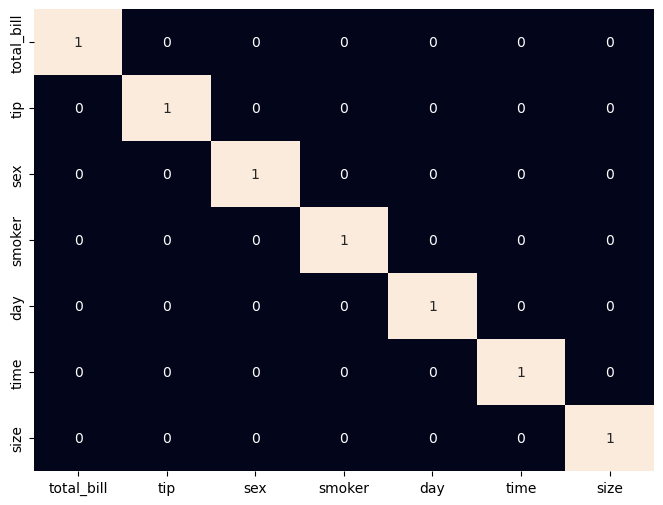

In [164]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr()>0.8,annot=True,cbar=False)
plt.show()

In [165]:
X=df.drop("tip",axis=1)
y=df.tip

In [166]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [167]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [168]:
models=[LinearRegression(),RandomForestRegressor(),AdaBoostRegressor()]
for i in range(3):
    models[i].fit(X_train,y_train)
    print(f'{models[i]}:')
    X_train_pred=models[i].predict(X_train)
    print("Training Accuracy:",mae(y_train,X_train_pred))

    y_pred_test = models[i].predict(X_test)
    print('Validation Accuracy : ', mae(y_test, y_pred_test))
    print()
    
    

LinearRegression():
Training Accuracy: 0.7639861000156479
Validation Accuracy :  0.6703807496461157

RandomForestRegressor():
Training Accuracy: 0.30757641025641025
Validation Accuracy :  0.7738755102040819

AdaBoostRegressor():
Training Accuracy: 0.687812795179365
Validation Accuracy :  0.8649414014667408



In [169]:
RFG=RandomForestRegressor()

In [170]:
RFG.fit(X_train,y_train)

RandomForestRegressor()

In [171]:
RFG.predict(X_test)

array([2.8907, 2.0099, 3.7634, 3.0655, 1.9291, 3.3039, 4.4564, 1.8541,
       2.2608, 2.5832, 3.4877, 2.1728, 1.9022, 2.3174, 1.7377, 2.9292,
       3.0087, 3.9035, 2.6445, 6.4683, 3.1953, 3.1614, 2.4489, 1.7651,
       3.7194, 2.1029, 2.2395, 3.4266, 2.8749, 7.5139, 5.5112, 2.4238,
       2.4776, 3.2797, 2.0134, 3.5111, 1.9121, 4.2456, 1.9439, 3.4347,
       2.0764, 2.2429, 3.5847, 2.095 , 2.1686, 1.3573, 2.0347, 3.0313,
       2.3948])